In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import Layer, Dense, Conv2D, Multiply, Permute, Reshape, GlobalAveragePooling2D, MultiHeadAttention, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc
from tensorflow.keras.applications import EfficientNetB3, DenseNet121, ResNet50, InceptionV3, VGG16
import kagglehub

2026-02-11 16:14:15.250133: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770826455.434150      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770826455.491026      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770826455.936507      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770826455.936548      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770826455.936551      24 computation_placer.cc:177] computation placer alr

In [2]:
path = kagglehub.dataset_download("andrewmvd/ocular-disease-recognition-odir5k")
df = pd.read_csv(os.path.join(path, 'full_df.csv'))

images = []
labels = []
image_size = 224

for index, row in df.iterrows():
    imgpath = os.path.join(path, "preprocessed_images", row['filename'])
    try:
        image = cv2.imread(imgpath)
        image = cv2.resize(image, (image_size, image_size))
        images.append(image)
        labels.append(row['labels'])
    except:
        continue

images = np.array(images)
labels = np.array(labels)

data_df = pd.DataFrame({'Image': list(images), 'Label': labels})
balanced_df = pd.DataFrame()
for label in data_df['Label'].unique():
    sampled = data_df[data_df['Label'] == label]
    if len(sampled) > 500:
        sampled = sampled.sample(500, random_state=42)
    else:
        sampled = sampled.sample(500, replace=True, random_state=42)
    balanced_df = pd.concat([balanced_df, sampled])

X_raw = np.stack(balanced_df['Image'].values)
y_raw = balanced_df['Label'].values

print(f"Data count before expansion: {len(X_raw)}")

Data count before expansion: 4000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Data count after expansion: 8000


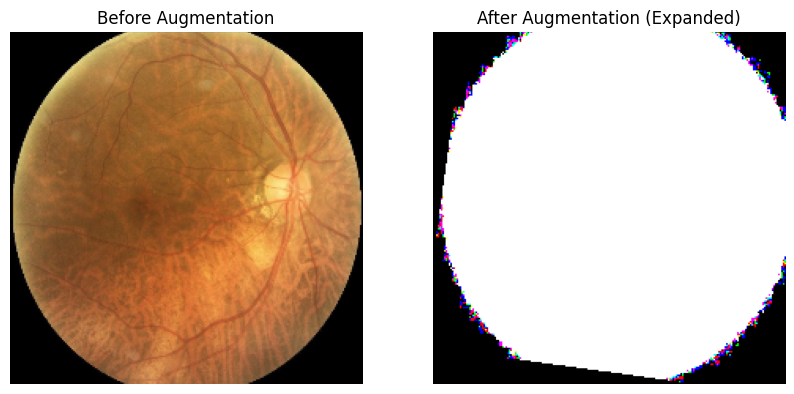

In [3]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='constant',
    cval=0
)

X_augmented = []
y_augmented = []

for i in range(len(X_raw)):
    img = X_raw[i]
    label = y_raw[i]
    X_augmented.append(img)
    y_augmented.append(label)
    
    aug_img = datagen.random_transform(img)
    X_augmented.append(aug_img)
    y_augmented.append(label)

X_augmented = np.array(X_augmented)
y_augmented = np.array(y_augmented)

encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y_augmented.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X_augmented, y_encoded, test_size=0.2, stratify=y_augmented, random_state=42)

print(f"Data count after expansion: {len(X_augmented)}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(X_raw[0], cv2.COLOR_BGR2RGB))
plt.title("Before Augmentation")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(X_augmented[1], cv2.COLOR_BGR2RGB))
plt.title("After Augmentation (Expanded)")
plt.axis('off')
plt.show()

In [4]:
class ChannelAttention(Layer):
    def __init__(self, channels, reduction_ratio=16, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.channels = channels
        self.reduction_ratio = reduction_ratio
        
    def build(self, input_shape):
        self.mlp = tf.keras.Sequential([
            layers.Dense(self.channels // self.reduction_ratio, activation='relu'),
            layers.Dense(self.channels, activation='sigmoid')
        ])
        super(ChannelAttention, self).build(input_shape)
        
    def call(self, x):
        batch, height, width, channels = tf.keras.backend.int_shape(x)
        x_permuted = Permute((3, 1, 2))(x)
        x_permuted = Reshape((channels, height * width))(x_permuted)
        x_squeezed = tf.reduce_mean(x_permuted, axis=-1)
        channel_attention = self.mlp(x_squeezed)
        channel_attention = Reshape((1, 1, channels))(channel_attention)
        return channel_attention
    
    def get_config(self):
        config = super(ChannelAttention, self).get_config()
        config.update({'channels': self.channels, 'reduction_ratio': self.reduction_ratio})
        return config

class SpatialAttention(Layer):
    def __init__(self, channels, reduction_ratio=16, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.channels = channels
        self.reduction_ratio = reduction_ratio
        
    def build(self, input_shape):
        self.conv1 = Conv2D(filters=self.channels // self.reduction_ratio, kernel_size=7, padding='same', activation='relu')
        self.conv2 = Conv2D(filters=1, kernel_size=7, padding='same', activation='sigmoid')
        super(SpatialAttention, self).build(input_shape)
        
    def call(self, x):
        spatial_attention = self.conv1(x)
        spatial_attention = self.conv2(spatial_attention)
        return spatial_attention
    
    def get_config(self):
        config = super(SpatialAttention, self).get_config()
        config.update({'channels': self.channels, 'reduction_ratio': self.reduction_ratio})
        return config

class GAM(Layer):
    def __init__(self, reduction_ratio=16, **kwargs):
        super(GAM, self).__init__(**kwargs)
        self.reduction_ratio = reduction_ratio
        
    def build(self, input_shape):
        channels = input_shape[-1]
        self.channel_attention = ChannelAttention(channels=channels, reduction_ratio=self.reduction_ratio)
        self.spatial_attention = SpatialAttention(channels=channels, reduction_ratio=self.reduction_ratio)
        super(GAM, self).build(input_shape)
        
    def call(self, x):
        channel_att = self.channel_attention(x)
        x = Multiply()([x, channel_att])
        spatial_att = self.spatial_attention(x)
        x = Multiply()([x, spatial_att])
        return x
    
    def get_config(self):
        config = super(GAM, self).get_config()
        config.update({'reduction_ratio': self.reduction_ratio})
        return config

class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="swish"), 
            Dense(embed_dim),
        ])
        self.layernorm1 = BatchNormalization()
        self.layernorm2 = BatchNormalization()
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=True):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)
    
    def get_config(self):
        config = super().get_config()
        return config

def multi_head_block(x, embed_dim, num_heads=8, key_dim=64):
    if embed_dim % num_heads != 0:
        embed_dim = (embed_dim // num_heads) * num_heads
        x = Dense(embed_dim)(x)
    
    seq_len = num_heads
    token_dim = embed_dim // num_heads
    
    x_reshaped = Reshape((seq_len, token_dim))(x)
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x_reshaped, x_reshaped)
    output = Reshape((embed_dim,))(attention_output)
    return output

In [5]:
def build_large_model(base_name, num_classes):
    input_layer = Input(shape=(image_size, image_size, 3))
    
    if base_name == 'EfficientNetB3':
        base = EfficientNetB3(include_top=False, input_tensor=input_layer, weights='imagenet')
        base.trainable = True
        for layer in base.layers[:-60]: layer.trainable = False
        x = base.output
        embed_dim = 1536
    elif base_name == 'DenseNet121':
        base = DenseNet121(include_top=False, input_tensor=input_layer, weights='imagenet')
        base.trainable = True
        for layer in base.layers[:-60]: layer.trainable = False
        x = base.output
        embed_dim = 1024
    elif base_name == 'ResNet50':
        base = ResNet50(include_top=False, input_tensor=input_layer, weights='imagenet')
        base.trainable = True
        for layer in base.layers[:-60]: layer.trainable = False
        x = base.output
        embed_dim = 2048
    elif base_name == 'InceptionV3':
        base = InceptionV3(include_top=False, input_tensor=input_layer, weights='imagenet')
        base.trainable = True
        for layer in base.layers[:-60]: layer.trainable = False
        x = base.output
        embed_dim = 2048
    elif base_name == 'VGG16':
        base = VGG16(include_top=False, input_tensor=input_layer, weights='imagenet')
        base.trainable = True
        for layer in base.layers[:-10]: layer.trainable = False
        x = base.output
        embed_dim = 512
    elif base_name == 'RetinaViT-AD':
        base = EfficientNetB3(include_top=False, input_tensor=input_layer, weights='imagenet')
        base.trainable = True
        for layer in base.layers[:-100]: layer.trainable = False
        x = base.output
        s = x.shape
        x = Reshape((s[1]*s[2], s[3]))(x)
        x = TransformerBlock(embed_dim=s[3], num_heads=8, ff_dim=2048)(x)
        x = Reshape((s[1], s[2], s[3]))(x)
        embed_dim = s[3]
        
    x = GAM()(x)
    x = GlobalAveragePooling2D()(x)
    
    x = multi_head_block(x, embed_dim=embed_dim)
    x = BatchNormalization()(x)
    x = Dense(1024, activation='swish')(x)
    x = Dropout(0.4)(x)
    
    x = Dense(512, activation='swish')(x)
    x = BatchNormalization()(x)
    
    x = multi_head_block(x, embed_dim=512)
    x = Dropout(0.3)(x)
    
    x = Dense(256, activation='swish')(x)
    x = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=x)
    model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [6]:
model_eff = build_large_model('EfficientNetB3', y_encoded.shape[1])
history_eff = model_eff.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5),
        ModelCheckpoint('effnet_best.keras', save_best_only=True)
    ]
)

I0000 00:00:1770826590.988650      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770826590.994667      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40


I0000 00:00:1770826626.497782      70 service.cc:152] XLA service 0x7e4810002970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770826626.497831      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770826626.497836      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770826631.184504      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-11 16:17:20.465953: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-11 16:17:20.606793: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-11 16:17:20.932150: E external/local_xl

400/400 ━━━━━━━━━━━━━━━━━━━━ 105s 113ms/step - accuracy: 0.4231 - loss: 1.5266 - val_accuracy: 0.4581 - val_loss: 1.6170 - learning_rate: 1.0000e-04
Epoch 2/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.6444 - loss: 0.9536 - val_accuracy: 0.7250 - val_loss: 0.6910 - learning_rate: 1.0000e-04
Epoch 3/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.7211 - loss: 0.7145 - val_accuracy: 0.7588 - val_loss: 0.6218 - learning_rate: 1.0000e-04
Epoch 4/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 35s 86ms/step - accuracy: 0.7636 - loss: 0.6142 - val_accuracy: 0.7781 - val_loss: 0.5944 - learning_rate: 1.0000e-04
Epoch 5/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.8014 - loss: 0.5286 - val_accuracy: 0.8119 - val_loss: 0.4974 - learning_rate: 1.0000e-04
Epoch 6/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.8414 - loss: 0.4335 - val_accuracy: 0.8150 - val_loss: 0.5143 - learning_rate: 1.0000e-04
Epoch 7/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - accur

In [7]:
model_dense = build_large_model('DenseNet121', y_encoded.shape[1])
history_dense = model_dense.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5),
        ModelCheckpoint('dense_best.keras', save_best_only=True)
    ]
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 92s 111ms/step - accuracy: 0.3240 - loss: 1.7767 - val_accuracy: 0.2744 - val_loss: 1.8345 - learning_rate: 1.0000e-04
Epoch 2/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.4852 - loss: 1.3313 - val_accuracy: 0.4787 - val_loss: 1.3745 - learning_rate: 1.0000e-04
Epoch 3/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.5514 - loss: 1.1696 - val_accuracy: 0.5569 - val_loss: 1.2169 - learning_rate: 1.0000e-04
Epoch 4/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.5860 - loss: 1.0547 - val_accuracy: 0.5800 - val_loss: 1.1366 - learning_rate: 1.0000e-04
Epoch 5/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.6140 - loss: 0.9923 - val_accuracy: 0.5981 - val_loss: 1.1314 - learning_rate: 1.0000e-04
Epoch 6/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.6533 - loss: 0.8843 - val_accuracy: 0.5781 - val_loss: 1.1021 - learning_rate: 1.0000e-04


In [8]:
model_res = build_large_model('ResNet50', y_encoded.shape[1])
history_res = model_res.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5),
        ModelCheckpoint('resnet_best.keras', save_best_only=True)
    ]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 104s 172ms/step - accuracy: 0.4539 - loss: 1.4887 - val_accuracy: 0.4925 - val_loss: 1.4265 - learning_rate: 1.0000e-04
Epoch 2/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 61s 153ms/step - accuracy: 0.6776 - loss: 0.8596 - val_accuracy: 0.7219 - val_loss: 0.7273 - learning_rate: 1.0000e-04
Epoch 3/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 58s 145ms/step - accuracy: 0.7709 - loss: 0.6061 - val_accuracy: 0.7100 - val_loss: 0.7732 - learning_rate: 1.0000e-04
Epoch 4/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 61s 151ms/step - accuracy: 0.8300 - loss: 0.4497 - val_accuracy: 0.7631 - val_loss: 0.7062 - learning_rate: 1.0000e-04
Epoch 5/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 61s 152ms/step - accuracy: 0.8860 - loss: 0.3220 - val_accuracy: 0.7887 - val_loss: 0.6407 - learning_rate: 1.0000e-04
Epoch 6/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 61s 151ms/step - accuracy: 0.9292 - loss: 0.2123 - val_accuracy: 0.8144 - val_loss: 0.5856 - learning_rate: 1.000

In [9]:
model_inception = build_large_model('InceptionV3', y_encoded.shape[1])
history_inception = model_inception.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5),
        ModelCheckpoint('inception_best.keras', save_best_only=True)
    ]
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 83s 121ms/step - accuracy: 0.3033 - loss: 1.8183 - val_accuracy: 0.3581 - val_loss: 1.7453 - learning_rate: 1.0000e-04
Epoch 2/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.4487 - loss: 1.4598 - val_accuracy: 0.4900 - val_loss: 1.3391 - learning_rate: 1.0000e-04
Epoch 3/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.5027 - loss: 1.3106 - val_accuracy: 0.4994 - val_loss: 1.3031 - learning_rate: 1.0000e-04
Epoch 4/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 35s 86ms/step - accuracy: 0.5568 - loss: 1.1674 - val_accuracy: 0.5119 - val_loss: 1.3866 - learning_rate: 1.0000e-04
Epoch 5/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.5824 - loss: 1.0842 - val_accuracy: 0.5219 - val_loss: 1.2801 - learning_rate: 1.0000e-04
Epoch 6/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 35s 86ms/step - accuracy: 0.6237 - loss: 0.9871 - val_accuracy: 0.5275 - val_loss: 1.3690 - learning_rate: 1.0000e-04


In [10]:
model_vgg = build_large_model('VGG16', y_encoded.shape[1])
history_vgg = model_vgg.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5),
        ModelCheckpoint('vgg_best.keras', save_best_only=True)
    ]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 124s 239ms/step - accuracy: 0.3314 - loss: 1.7521 - val_accuracy: 0.3738 - val_loss: 1.5883 - learning_rate: 1.0000e-04
Epoch 2/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 87s 218ms/step - accuracy: 0.3255 - loss: 1.6895 - val_accuracy: 0.1937 - val_loss: 2.0420 - learning_rate: 1.0000e-04
Epoch 3/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 87s 218ms/step - accuracy: 0.3422 - loss: 1.6283 - val_accuracy: 0.2819 - val_loss: 1.7652 - learning_rate: 1.0000e-04
Epoch 4/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 87s 217ms/step - accuracy: 0.3329 - loss: 1.6659 - val_accuracy: 0.1219 - val_loss: 2.2100 - learning_rate: 1.0000e-04
Epoch 5/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 86s 215ms/step - accuracy: 0.2266 - loss: 1.9541 - val_accuracy: 0.3506 - val_loss: 1.6521 - learning_rate: 1.0000e-04
Epoch 6/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 86s 215ms/step - accuracy: 0.2974 - loss: 1.7729 - val_accuracy: 0.2406 - val_loss: 2.6691 - learning_rate: 1.000

In [11]:
model_retina = build_large_model('RetinaViT-AD', y_encoded.shape[1])
history_retina = model_retina.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    callbacks=[
        EarlyStopping(patience=12, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5),
        ModelCheckpoint('retinavit_best.keras', save_best_only=True)
    ]
)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 219s 377ms/step - accuracy: 0.4288 - loss: 1.5393 - val_accuracy: 0.6450 - val_loss: 0.9965 - learning_rate: 1.0000e-04
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 140s 349ms/step - accuracy: 0.6281 - loss: 1.0347 - val_accuracy: 0.6531 - val_loss: 0.9026 - learning_rate: 1.0000e-04
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 139s 346ms/step - accuracy: 0.6738 - loss: 0.8654 - val_accuracy: 0.7188 - val_loss: 0.7187 - learning_rate: 1.0000e-04
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 138s 346ms/step - accuracy: 0.7435 - loss: 0.6997 - val_accuracy: 0.7400 - val_loss: 0.7129 - learning_rate: 1.0000e-04
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 139s 347ms/step - accuracy: 0.7718 - loss: 0.5991 - val_accuracy: 0.7788 - val_loss: 0.5538 - learning_rate: 1.0000e-04
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 132s 330ms/step - accuracy: 0.8049 - loss: 0.5118 - val_accuracy: 0.7931 - val_loss: 0.5650 - learning_rate: 1.0000e-04
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 

In [12]:
def evaluate_and_plot(model, history, X_test, y_test, name):
    y_prob = model.predict(X_test)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    print(f"\n--- {name} Results ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{name} Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{name} Loss')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Greens')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

    plt.figure(figsize=(10, 7))
    for i in range(y_test.shape[1]):
        fpr, tpr, _ = roc_curve(y_test[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'{name} ROC Curves')
    plt.legend()
    plt.show()

2026-02-11 19:47:22.226050: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-11 19:47:22.371598: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-11 19:47:22.744329: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-11 19:47:22.891266: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-11 19:47:23.629513: E external/local_xla/xla/stream_

50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step

--- EfficientNetB3 Results ---
Accuracy: 0.9231
Precision: 0.9236
Recall: 0.9231
F1 Score: 0.9231


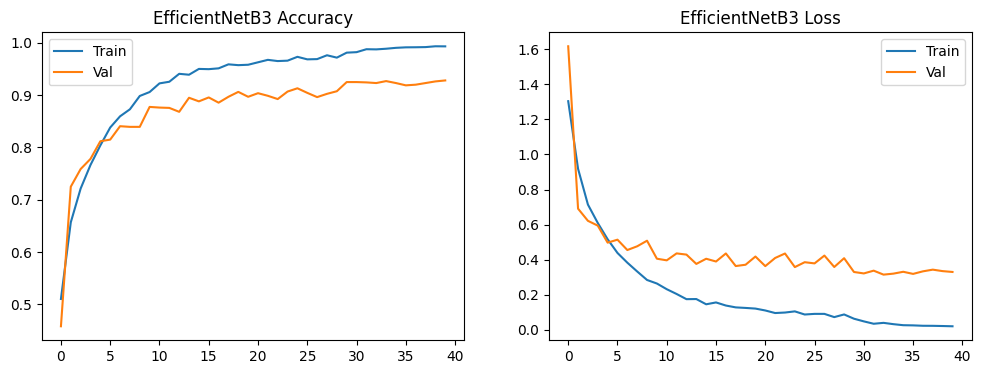

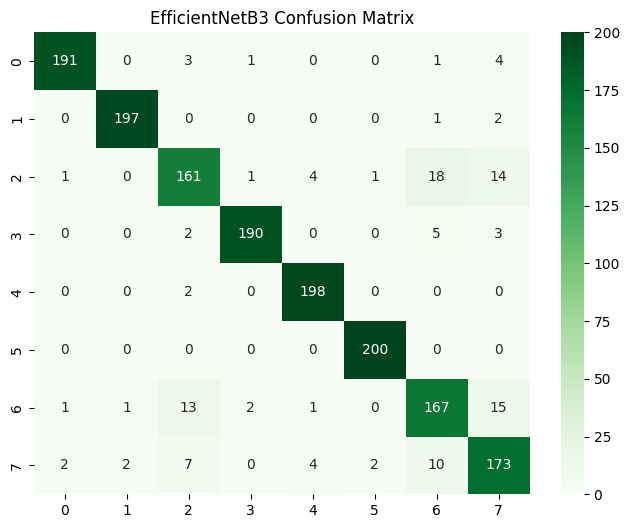

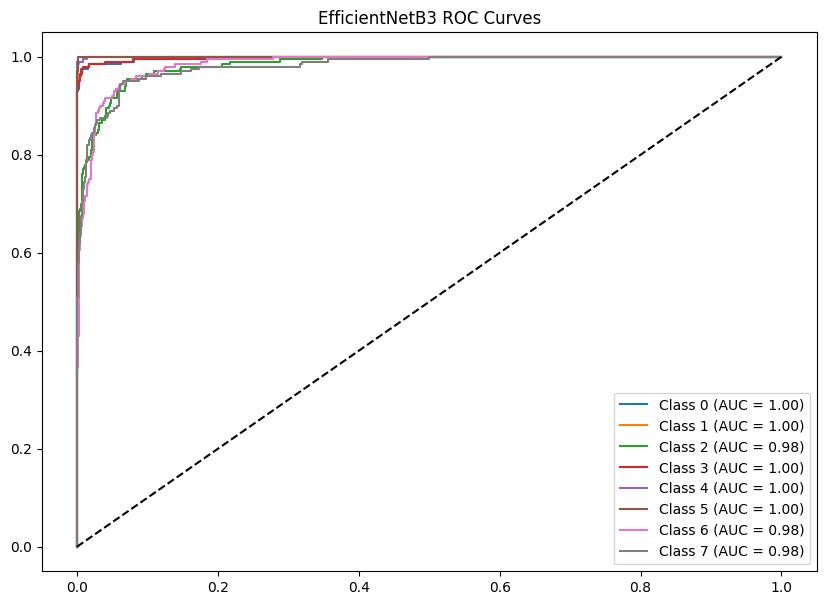

50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step

--- DenseNet121 Results ---
Accuracy: 0.6663
Precision: 0.6662
Recall: 0.6663
F1 Score: 0.6645


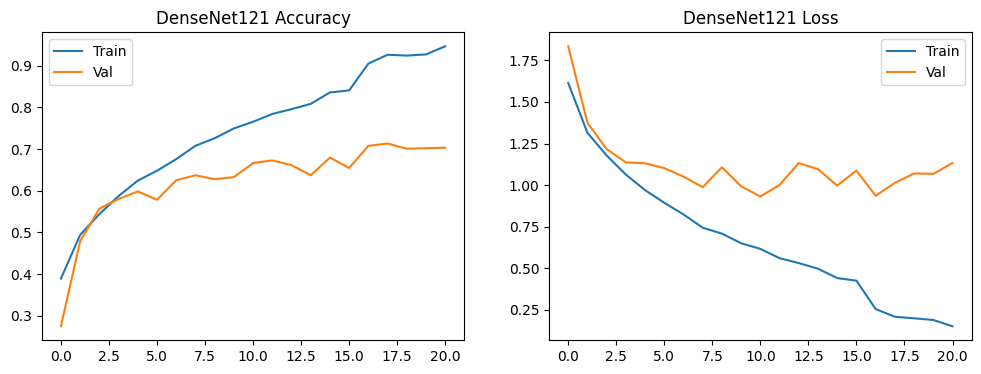

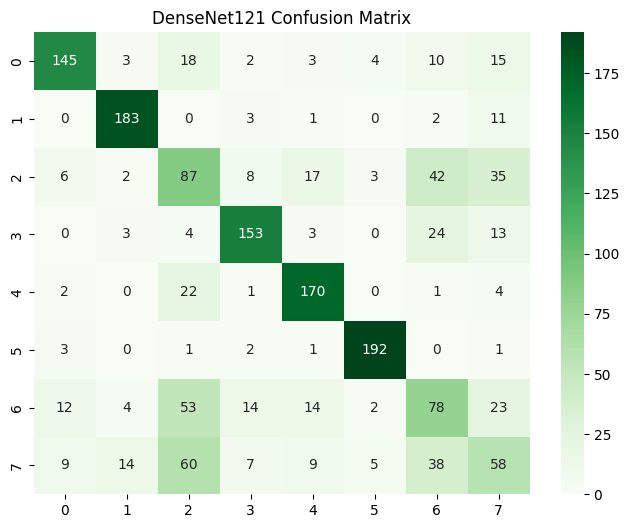

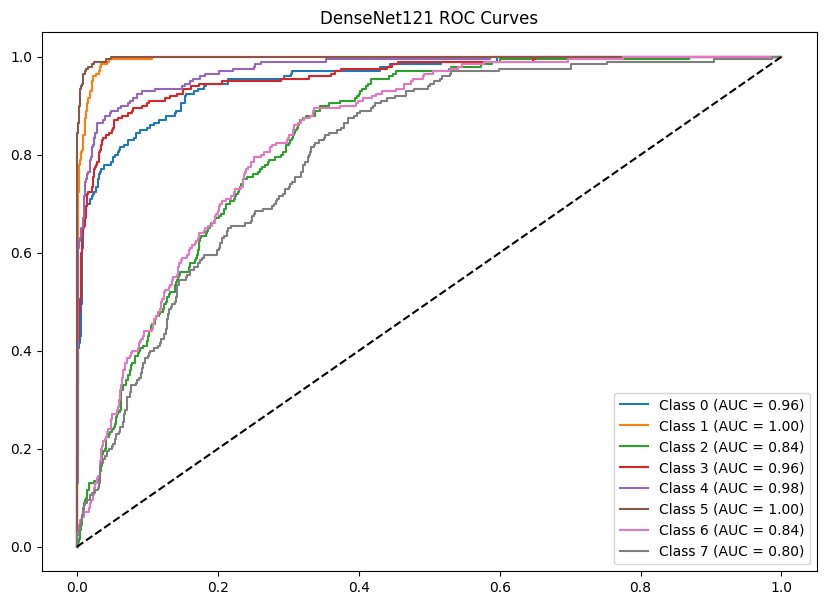

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 128ms/step

--- ResNet50 Results ---
Accuracy: 0.8550
Precision: 0.8592
Recall: 0.8550
F1 Score: 0.8552


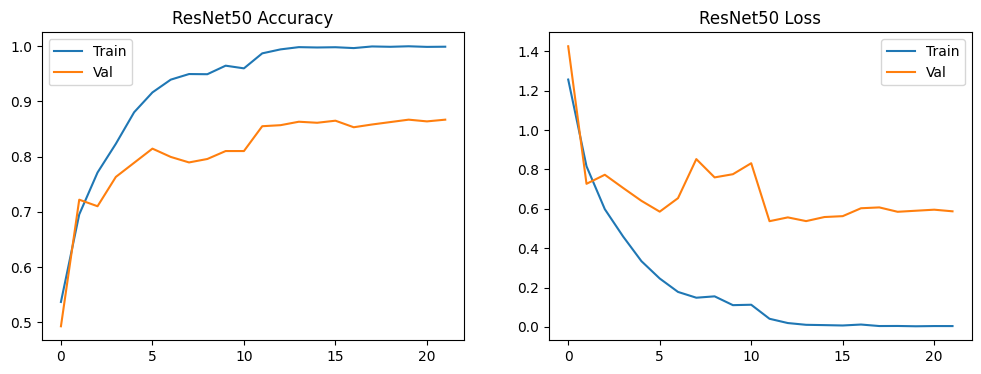

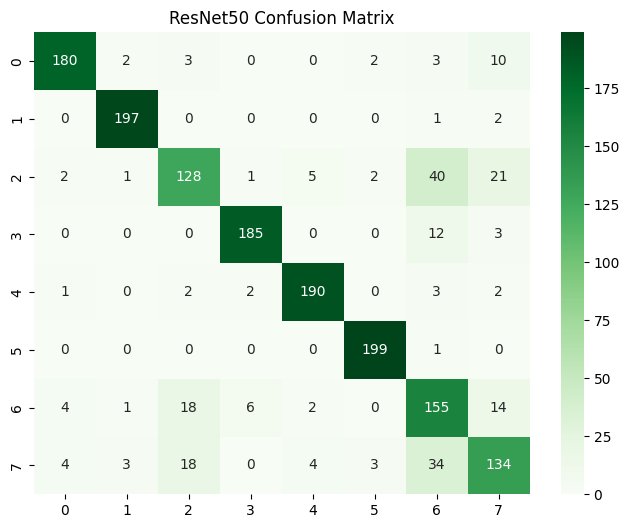

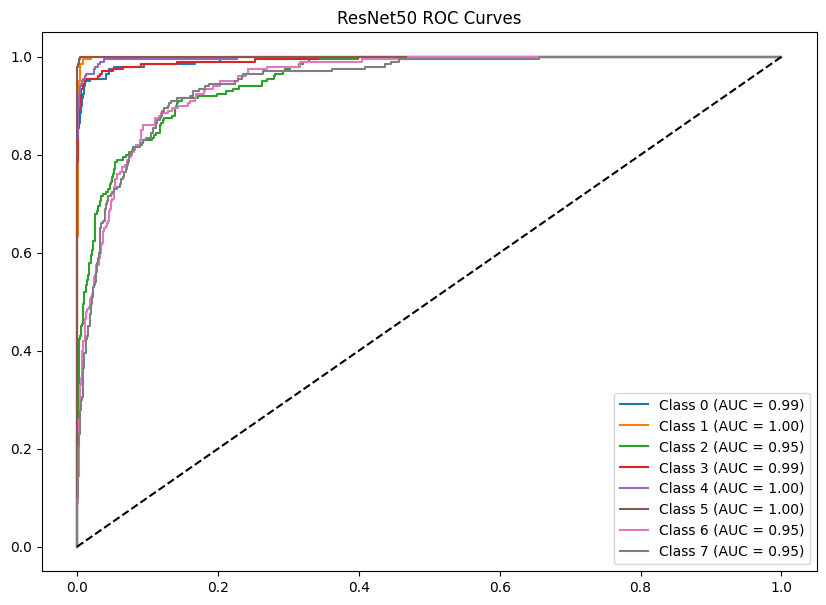

50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 169ms/step

--- RetinaViT-AD Results ---
Accuracy: 0.9169
Precision: 0.9183
Recall: 0.9169
F1 Score: 0.9173


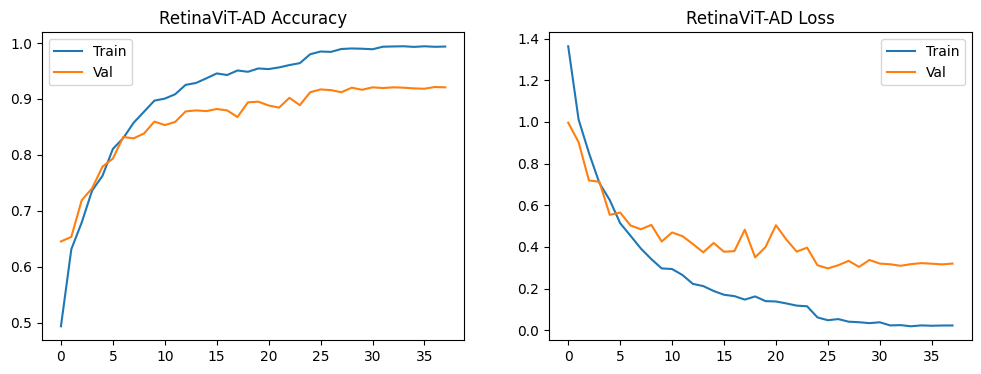

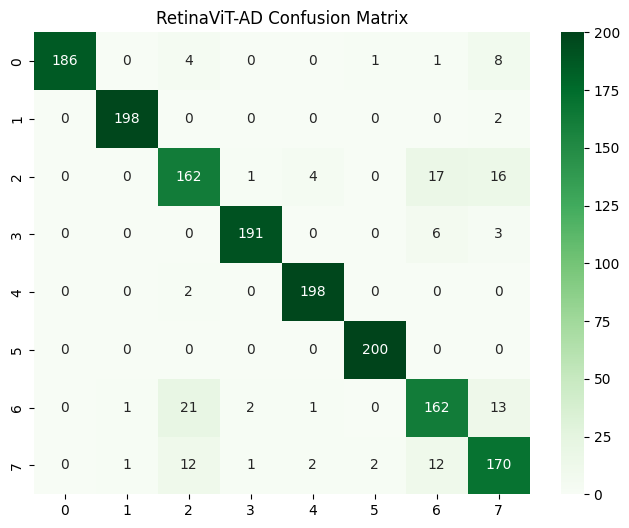

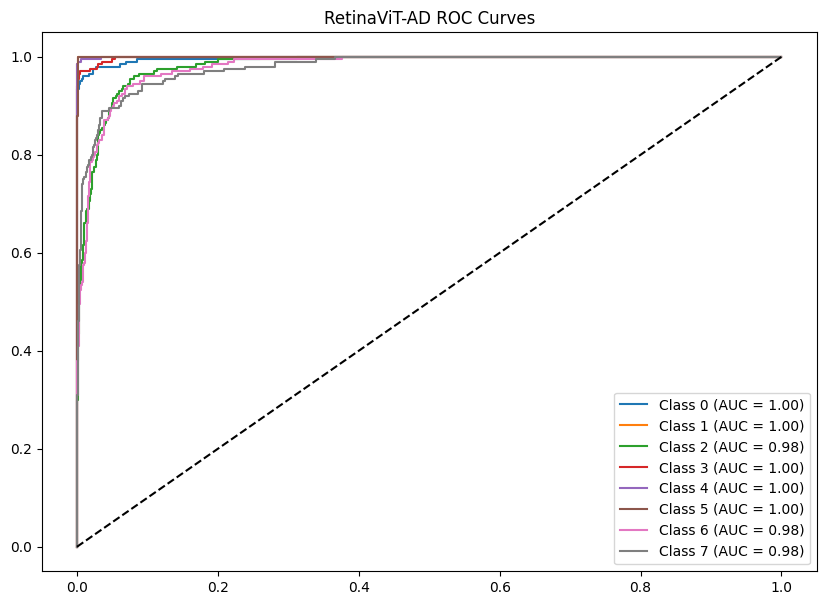

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step

--- InceptionV3 Results ---
Accuracy: 0.6550
Precision: 0.6675
Recall: 0.6550
F1 Score: 0.6597


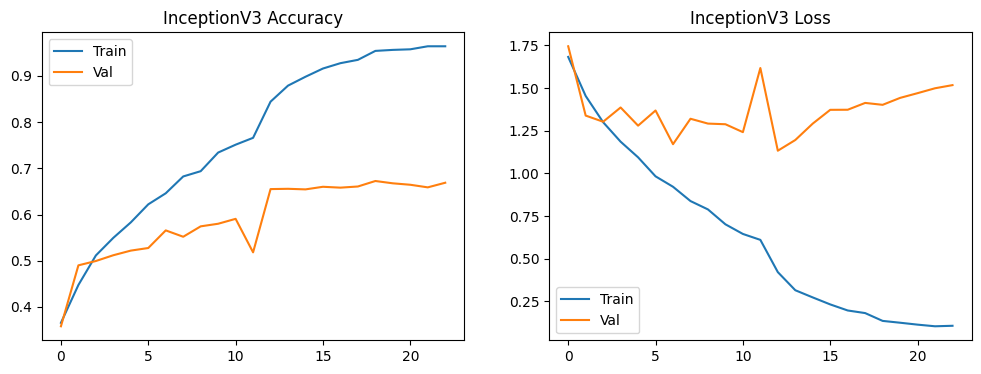

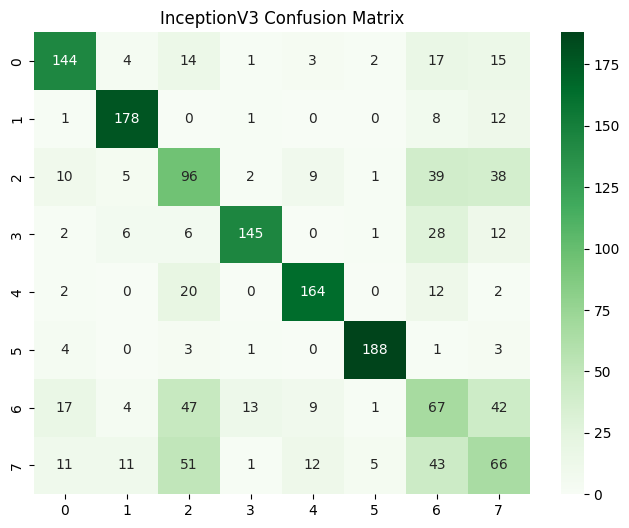

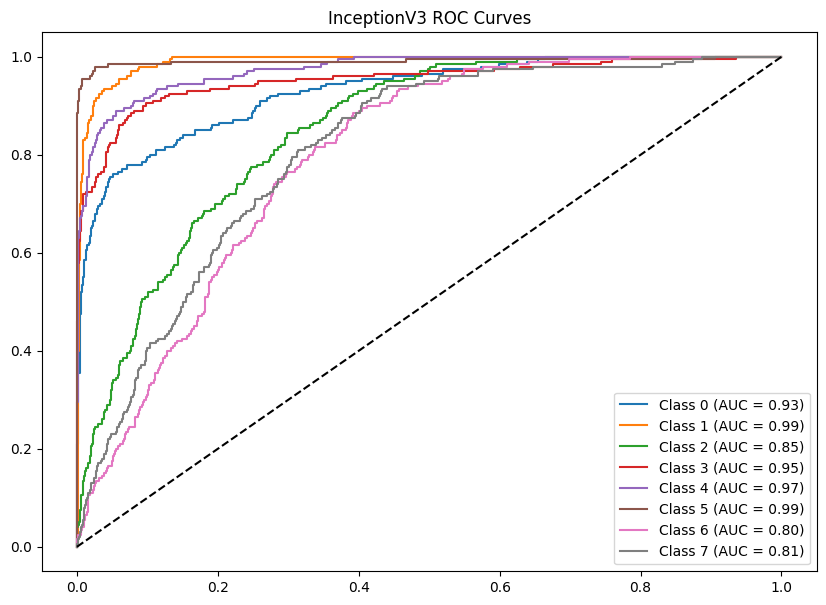

50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 207ms/step

--- VGG16 Results ---
Accuracy: 0.4794
Precision: 0.4228
Recall: 0.4794
F1 Score: 0.4416


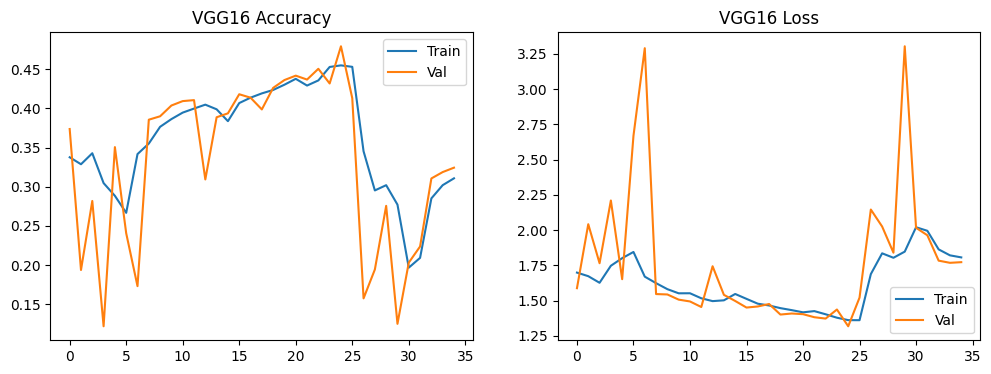

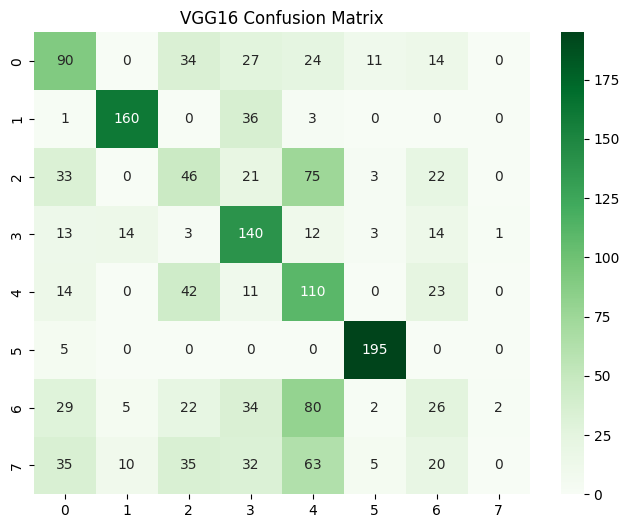

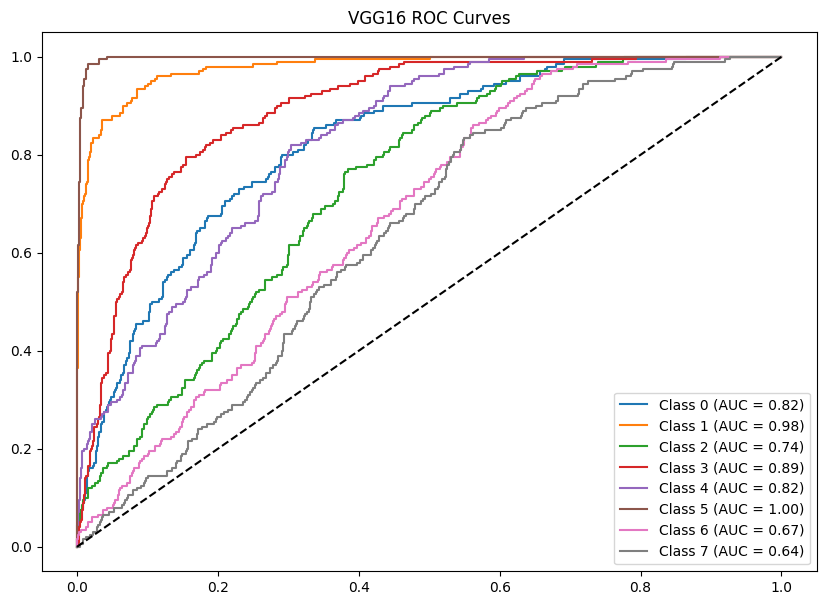

In [13]:
evaluate_and_plot(model_eff, history_eff, X_test, y_test, "EfficientNetB3")
evaluate_and_plot(model_dense, history_dense, X_test, y_test, "DenseNet121")
evaluate_and_plot(model_res, history_res, X_test, y_test, "ResNet50")
evaluate_and_plot(model_retina, history_retina, X_test, y_test, "RetinaViT-AD")
evaluate_and_plot(model_inception, history_inception, X_test, y_test, "InceptionV3")
evaluate_and_plot(model_vgg, history_vgg, X_test, y_test, "VGG16")